<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/DeepLearning1_23_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score,adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [29]:
#Veri setini yükleme ve birleştirme
red=pd.read_csv("winequality-red.csv",sep=";")
white=pd.read_csv("winequality-white.csv",sep=";")
red["type"]="red"
white["type"]="white"

df=pd.concat([red,white],ignore_index=True)
print(f"veri boyutu:{df.shape}")
df.info()

veri boyutu:(6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [30]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [31]:
print(f"Tekrarlanan satir sayisi: {df.duplicated().sum()}")
df=df.drop_duplicates().reset_index(drop=True)
print(f"Tekrarlar silindikten sonra veri boyutu: {df.shape}")

Tekrarlanan satir sayisi: 1177
Tekrarlar silindikten sonra veri boyutu: (5320, 13)


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,5320.0,7.215179,1.319671,3.80000,6.4000,7.00000,7.70000,15.90000
volatile acidity,5320.0,0.344130,0.168248,0.08000,0.2300,0.30000,0.41000,1.58000
citric acid,5320.0,0.318494,0.147157,0.00000,0.2400,0.31000,0.40000,1.66000
residual sugar,5320.0,5.048477,4.500180,0.60000,1.8000,2.70000,7.50000,65.80000
chlorides,5320.0,0.056690,0.036863,0.00900,0.0380,0.04700,0.06600,0.61100
free sulfur dioxide,5320.0,30.036654,17.805045,1.00000,16.0000,28.00000,41.00000,289.00000
total sulfur dioxide,5320.0,114.109023,56.774223,6.00000,74.0000,116.00000,153.25000,440.00000
density,5320.0,0.994535,0.002966,0.98711,0.9922,0.99465,0.99677,1.03898
pH,5320.0,3.224664,0.160379,2.72000,3.1100,3.21000,3.33000,4.01000
sulphates,5320.0,0.533357,0.149743,0.22000,0.4300,0.51000,0.60000,2.00000


In [32]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red


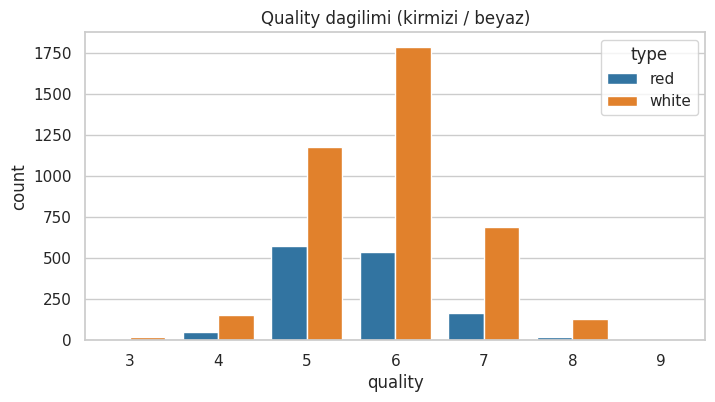

In [33]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="quality",hue="type")
plt.title("Quality dagilimi (kirmizi / beyaz)")
plt.show()

In [34]:
#quality ve type cikariliyor
features=df.drop(columns=["quality","type"])
imputer =SimpleImputer(strategy="mean")
df_imputed =pd.DataFrame(imputer.fit_transform(features),columns=features.columns,index=features.index)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")

Eksik deger kaldi mi: 0


In [35]:
scaler =StandardScaler()
X_scaled =scaler.fit_transform(df_imputed)
df_scaled =pd.DataFrame(X_scaled,columns=df_imputed.columns,index=df_imputed.index)
df_scaled.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833


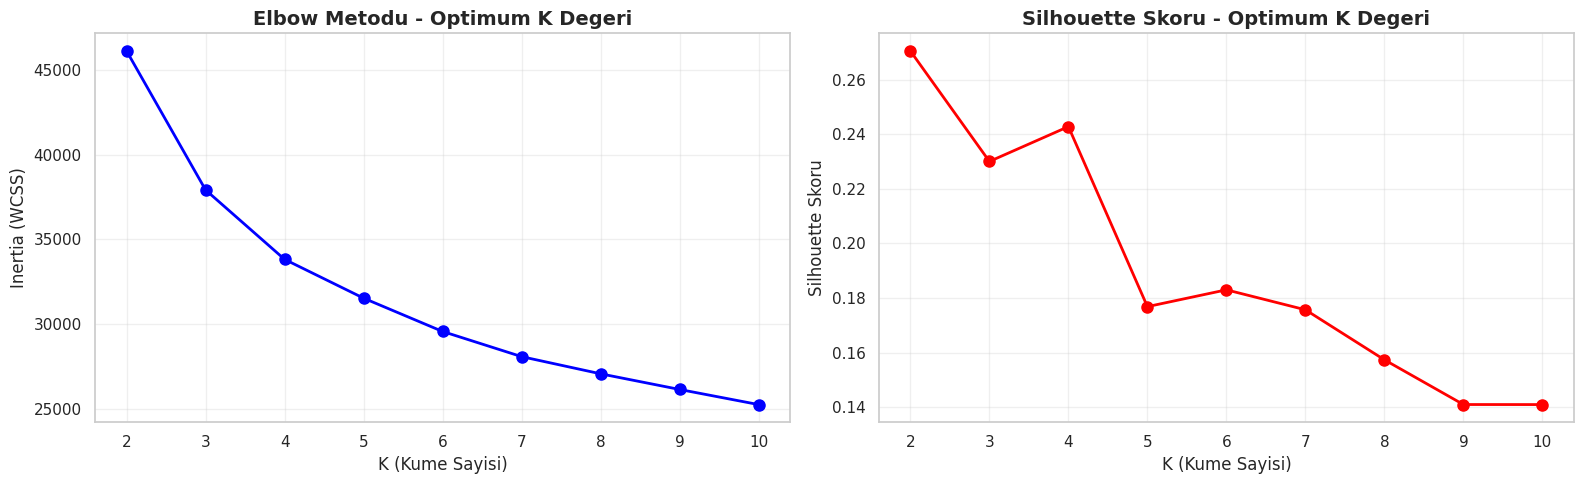

En iyi silhouette skoru: 0.2704
Optimum K degeri: 2


In [36]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

#Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [37]:
optimal_k = 2  # Elbow ve silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

print(f'\nAdjusted Rand Index (type ile): {adjusted_rand_score(df["type"], kmeans_labels):.4f}')
print(pd.crosstab(kmeans_labels, df["type"], rownames=["Kume"], colnames=["Tur"]))

K-Means Kumeleme Sonuclari:
Kume sayisi: 2
Silhouette Skoru: 0.2704
Davies-Bouldin Indeksi: 1.6263
Calinski-Harabasz Skoru: 1433.4099

Kume dagilimi:
0    3918
1    1402
Name: count, dtype: int64

Adjusted Rand Index (type ile): 0.9320
Tur    red  white
Kume             
0       22   3896
1     1337     65


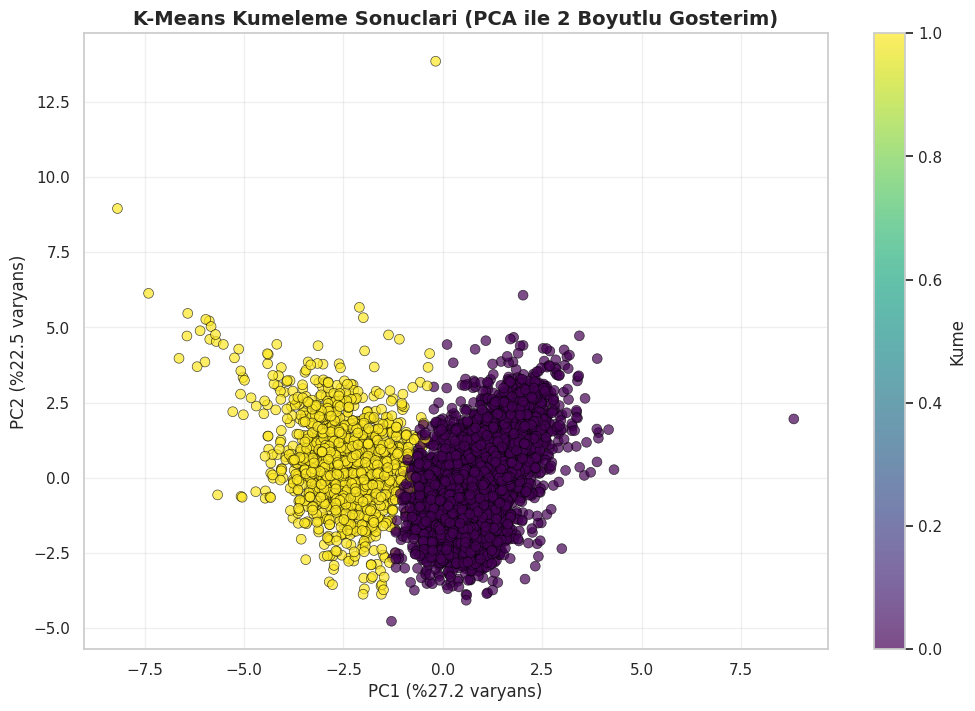

In [38]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

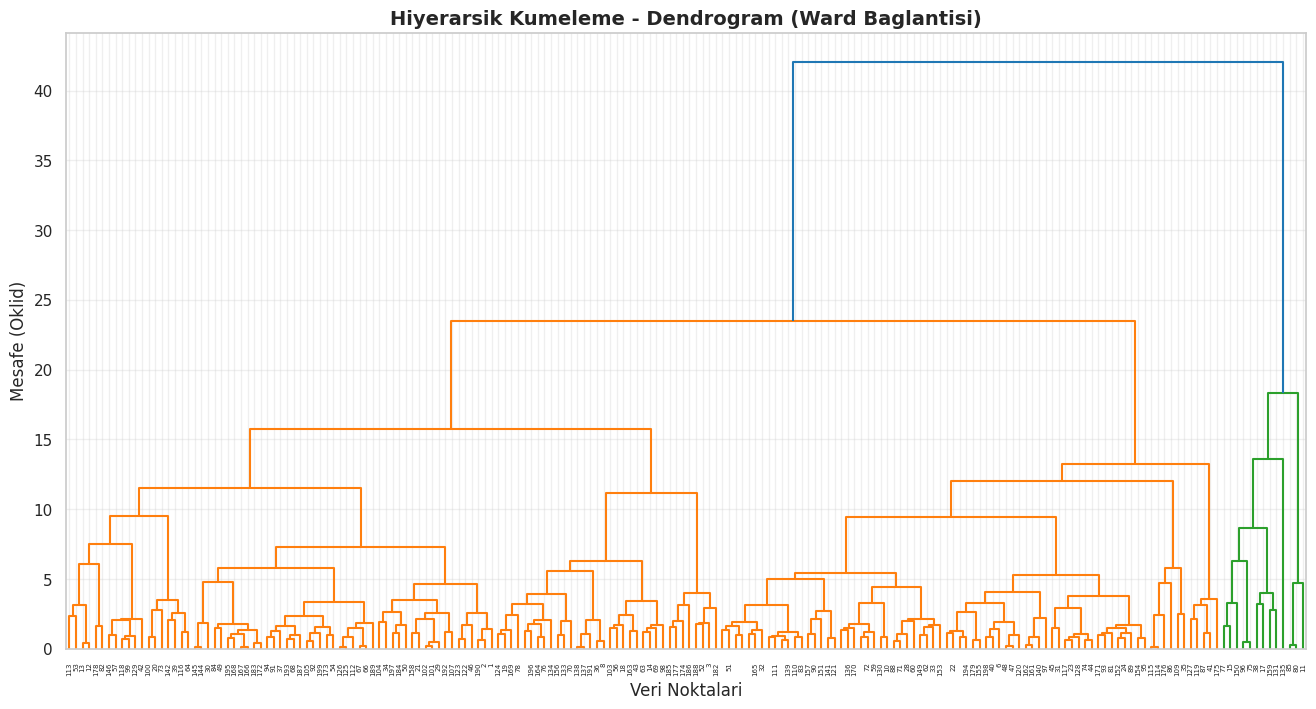

In [39]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())
print(f'\nAdjusted Rand Index (type ile): {adjusted_rand_score(df["type"], agg_labels):.4f}')

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 2
Baglanti yontemi: ward
Silhouette Skoru: 0.2607
Davies-Bouldin Indeksi: 1.7164
Calinski-Harabasz Skoru: 1345.3479

Kume dagilimi:
0    3842
1    1478
Name: count, dtype: int64

Adjusted Rand Index (type ile): 0.8753


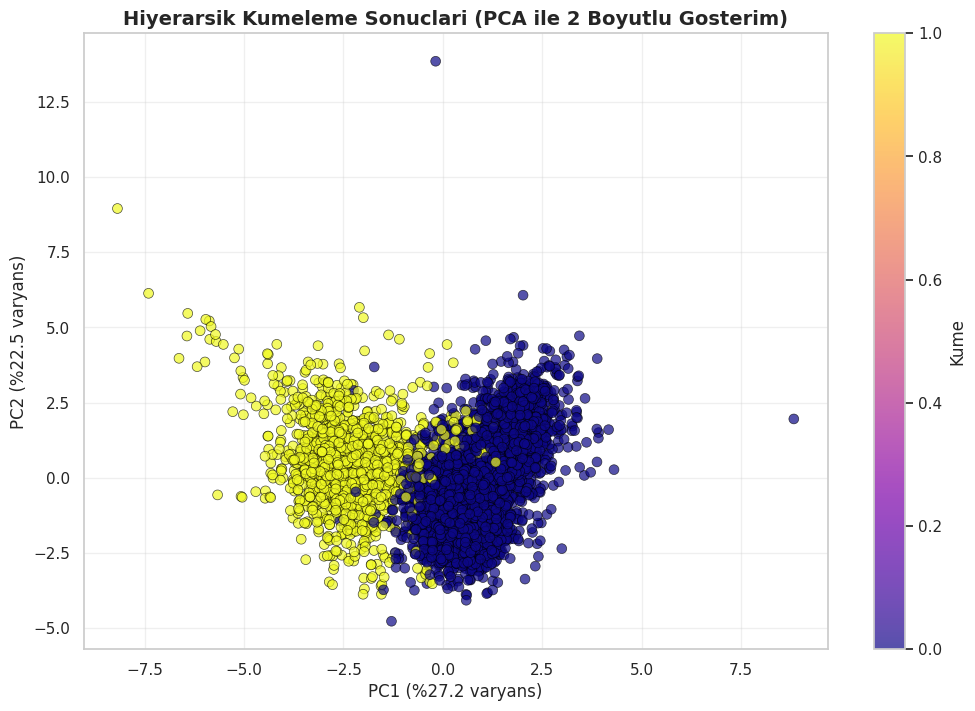

In [41]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

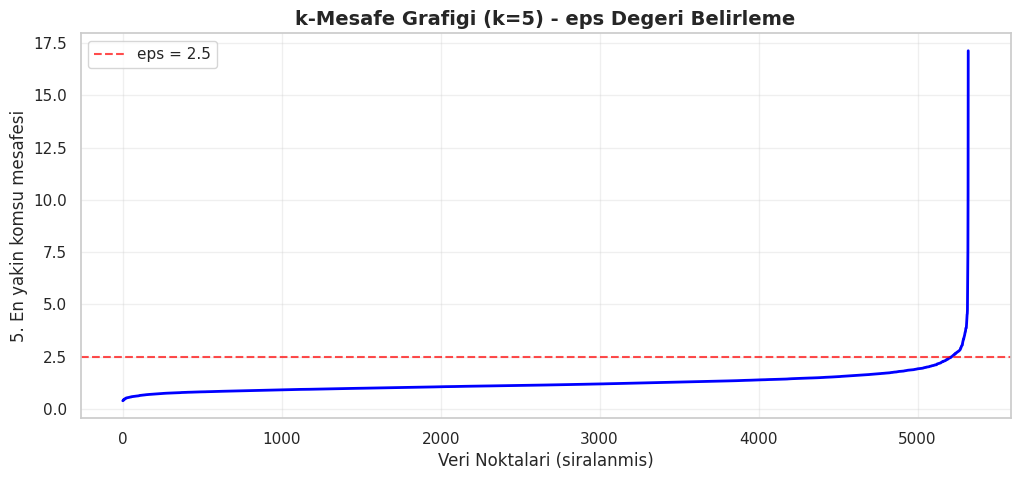

In [42]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
#DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 2.5, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kumeleme Sonuclari:
eps: 2.5, min_samples: 5
Olusan kume sayisi: 2
Gurultu (aykiri deger) sayisi: 53
Gurultu orani: 1.00%
Silhouette Skoru: 0.4767
Davies-Bouldin Indeksi: 2.0502
Calinski-Harabasz Skoru: 120.9054

Kume dagilimi:
-1      53
 0    5252
 1      15
Name: count, dtype: int64


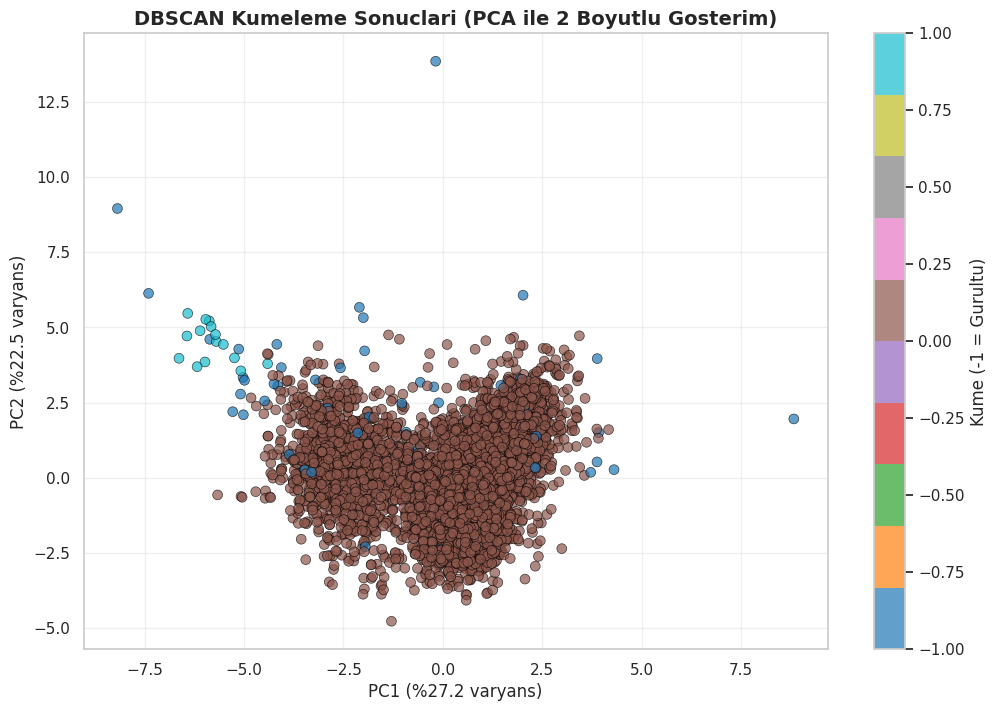

In [44]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
#Decision Tree
import random
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay,RocCurveDisplay)

In [48]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)

#quality >= 7 ise iyi sarap(1),degilse normal(0)
X = df.drop(columns=["quality","type"])
X["is_red"] = (df["type"]=="red").astype(int)
y = (df["quality"]>=7).astype(int)
class_names = ["normal","iyi"]
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

quality
0    4311
1    1009
Name: count, dtype: int64


In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10],
                          "class_weight":[None,"balanced"]
                      },
                      cv=cv ,scoring="f1",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)

En iyi parametre: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'splitter': 'best'}


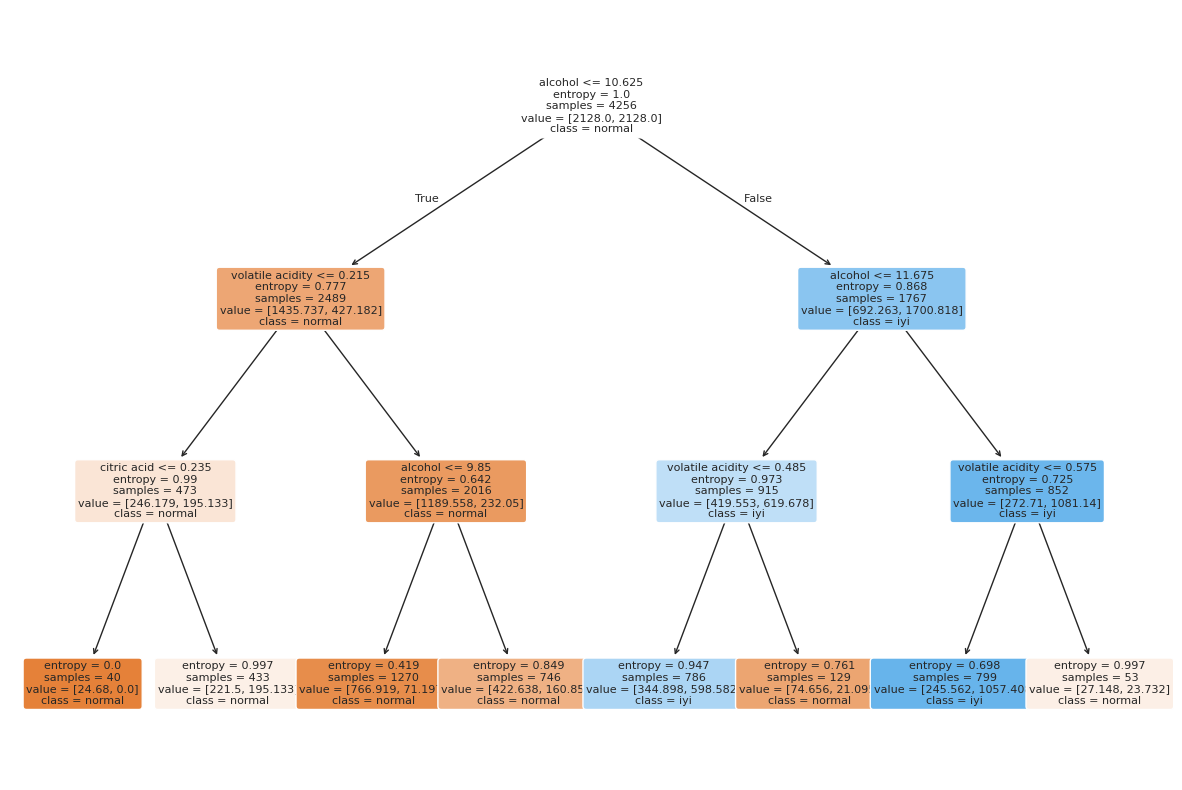

In [50]:
plt.figure(figsize=(15,10))
plot_tree(dt,feature_names=X.columns,class_names=class_names,
          filled=True,rounded= True, max_depth= 3, fontsize =8)
plt.savefig("decision_tree.png", dpi=150)
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf_grid= GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators":[100,200],
                          "max_depth":[7,10],
                          "min_samples_leaf" :[1,3],
                          "max_features":["sqrt","log2"],
                          "criterion":["gini","entropy"],
                          "class_weight":[None,"balanced"]
                      },
                      cv=cv ,scoring="f1",n_jobs=-1,verbose =3)
rf_grid.fit(X_train,y_train)
rf=rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
En iyi parametre: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 100}


In [52]:
for name,model in [("Decision Tree" ,dt),("Random Forest",rf)]:
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    cv_scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="f1")
    print(f"======== {name} ========")
    print(f"Test dogrulugu: {accuracy_score(y_test,y_pred):.4f}")
    print(f"Test F1: {f1_score(y_test,y_pred):.4f}")
    print(f"Ortalama 5 katli CV F1: {np.mean(cv_scores):.4f}")
    print(classification_report(y_test,y_pred,target_names=class_names))

======== Decision Tree ========
Test dogrulugu: 0.7086
Test F1: 0.4884
Ortalama 5 katli CV F1: 0.5124
              precision    recall  f1-score   support

      normal       0.92      0.70      0.80       862
         iyi       0.37      0.73      0.49       202

    accuracy                           0.71      1064
   macro avg       0.64      0.72      0.64      1064
weighted avg       0.81      0.71      0.74      1064

======== Random Forest ========
Test dogrulugu: 0.8083
Test F1: 0.5820
Ortalama 5 katli CV F1: 0.5583
              precision    recall  f1-score   support

      normal       0.92      0.83      0.88       862
         iyi       0.50      0.70      0.58       202

    accuracy                           0.81      1064
   macro avg       0.71      0.77      0.73      1064
weighted avg       0.84      0.81      0.82      1064



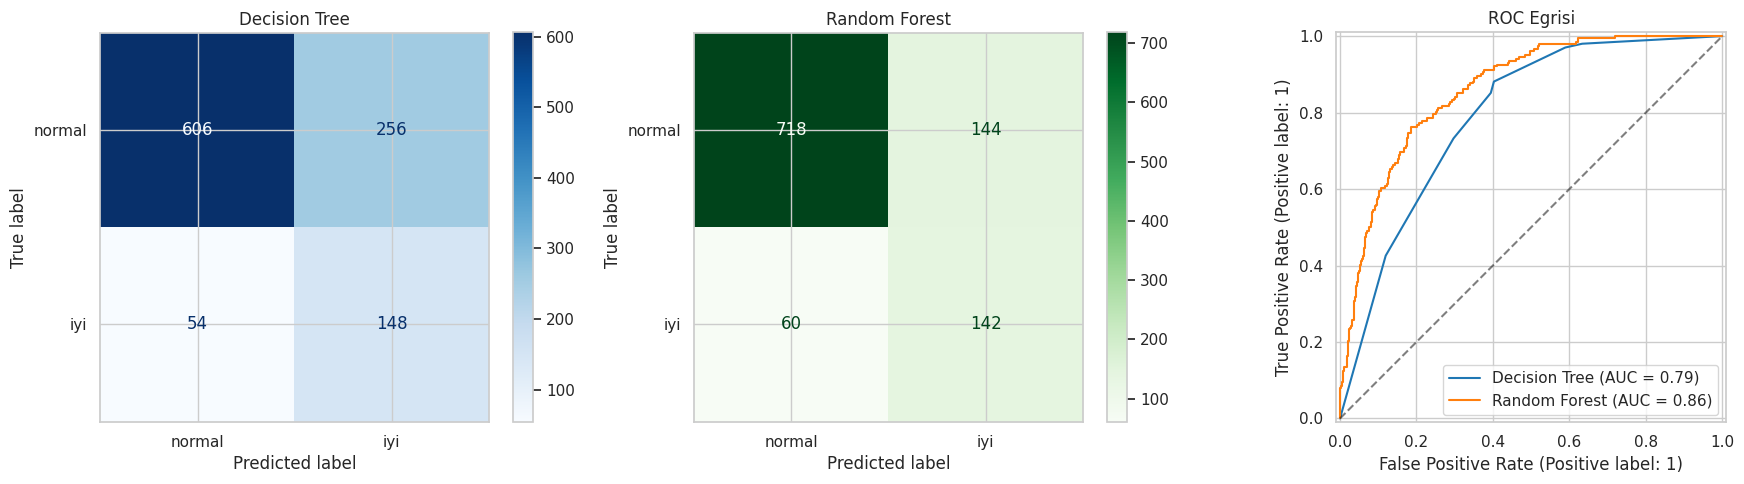

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, display_labels=class_names, cmap="Blues", ax=axes[0])
axes[0].set_title("Decision Tree")
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=class_names, cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest")
RocCurveDisplay.from_estimator(dt, X_test, y_test, ax=axes[2], name="Decision Tree")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[2], name="Random Forest")
axes[2].plot([0,1],[0,1],"k--",alpha=0.5)
axes[2].set_title("ROC Egrisi")
plt.tight_layout()
plt.savefig("confusion_roc.png", dpi=150)
plt.show()

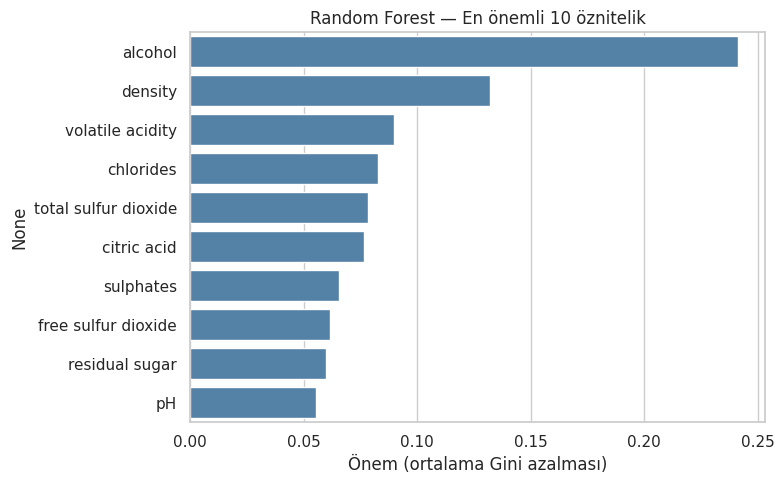

Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png


In [54]:
imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Önem (ortalama Gini azalması)")
plt.title("Random Forest — En önemli 10 öznitelik")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png")